In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
def getStuff(s,l=0,h=10):
    msg = s + "/" + s + "_accs"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", index_col=0)')

    df = pd.DataFrame(data=[eval('df' + str(i) + '.iloc[-1]') for i in range(l,h)])
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [89]:
def getStuffTimes(s,l=0,h=10):
    msg = s + "/" + s + "_times"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", header=None)')
        #print(eval('df' + str(i)))

    df = pd.DataFrame(data=[eval('df' + str(i) + '[0]') for i in range(l,h)])
    df = df[df.columns[0:2]]
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [98]:
augmean, augstd, augmedian, augiqr = getStuff("aug")
vanmean, vanstd, vanmedian, vaniqr = getStuff("base")
symmean, symstd, symmedian, symiqr = getStuff("sym")
symaugmean, symaugstd, symaugmedian, symaugiqr = getStuff("symaug",h=5)

In [99]:
augmeant, augstdt, augmediant, augiqrt = getStuffTimes("aug")
vanmeant, vanstdt, vanmediant, vaniqrt = getStuffTimes("base")
symmeant, symstdt, symmediant, symiqrt = getStuffTimes("sym")
symaugmeant, symaugstdt, symaugmediant, symaugiqrt = getStuffTimes("symaug",h=5)

In [100]:
augmediant

0    4.115827
1    4.056274
dtype: float64

In [101]:
augiqrt

0    0.069167
1    0.044408
dtype: float64

In [102]:
symmediant

0    4.195490
1    4.143754
dtype: float64

In [103]:
symiqrt

0    0.086302
1    0.034430
dtype: float64

In [104]:
symaugmediant

0    4.041304
1    4.037715
dtype: float64

In [105]:
symaugiqrt

0    0.025155
1    0.006443
dtype: float64

In [106]:
vanmediant

0    4.085758
1    4.068712
dtype: float64

In [107]:
vaniqrt

0    0.058790
1    0.038489
dtype: float64

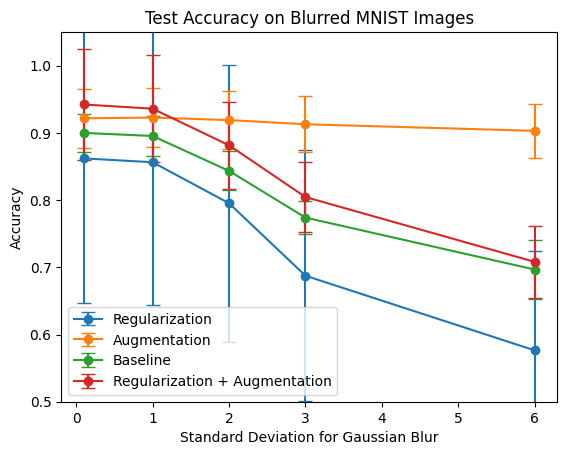

In [108]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmean, yerr=symstd, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmean, yerr=augstd, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmean, yerr=vanstd, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmean, yerr=symaugstd, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred MNIST Images')
plt.xlabel('Standard Deviation for Gaussian Blur')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0.5,1.05)
#plt.savefig("CIFAR10_Blur.pdf")
plt.show()

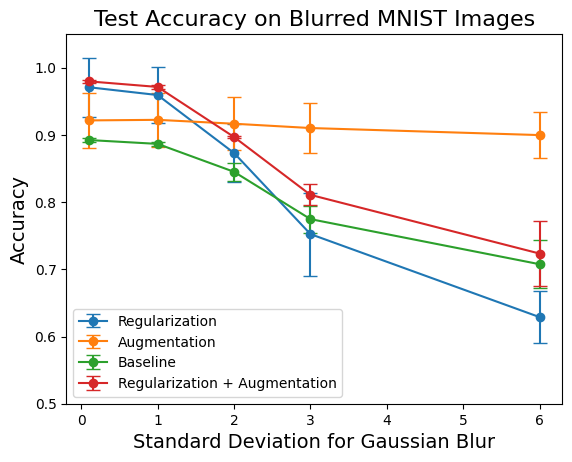

In [112]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmedian, yerr=symiqr, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmedian, yerr=augiqr, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmedian, yerr=vaniqr, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmedian, yerr=symaugiqr, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred MNIST Images', fontsize=16)
plt.xlabel('Standard Deviation for Gaussian Blur', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.ylim(0.5,1.05)
#plt.savefig("CIFAR10_Blur-2.pdf")
plt.show()

In [113]:
augmean

0    0.92176
1    0.92289
2    0.91910
3    0.91291
4    0.90307
dtype: float64

In [114]:
augstd

0    0.044265
1    0.044328
2    0.043405
3    0.041882
4    0.040003
dtype: float64

In [115]:
symmean

0    0.86210
1    0.85639
2    0.79536
3    0.68748
4    0.57640
dtype: float64

In [116]:
symstd

0    0.215400
1    0.213196
2    0.206245
3    0.186894
4    0.147294
dtype: float64

In [117]:
vanmean

0    0.90004
1    0.89547
2    0.84347
3    0.77401
4    0.69668
dtype: float64

In [118]:
vanstd

0    0.028235
1    0.029192
2    0.029039
3    0.024052
4    0.044320
dtype: float64

In [119]:
augmedian

0    0.92160
1    0.92245
2    0.91665
3    0.91025
4    0.89975
dtype: float64

In [120]:
augiqr

0    0.040912
1    0.040463
2    0.039062
3    0.037087
4    0.034600
dtype: float64

In [121]:
symmedian

0    0.97095
1    0.95935
2    0.87310
3    0.75240
4    0.62880
dtype: float64

In [122]:
symiqr

0    0.043850
1    0.042138
2    0.043788
3    0.061775
4    0.038875
dtype: float64

In [123]:
vanmedian

0    0.89240
1    0.88665
2    0.84510
3    0.77470
4    0.70755
dtype: float64

In [124]:
vaniqr

0    0.002387
1    0.002738
2    0.013775
3    0.020087
4    0.035413
dtype: float64

In [125]:
symaugmedian

0    0.9797
1    0.9714
2    0.8969
3    0.8108
4    0.7234
dtype: float64

In [126]:
symaugiqr

0    0.00220
1    0.00335
2    0.00215
3    0.01560
4    0.04850
dtype: float64